### Génération de polaires - Regression

PERFORMANCE DU MODÈLE
R² Score:           0.7903 (0-1, 1 = parfait)
Mean Squared Error: 2.5211
Root Mean Squared Error: 1.5878 nœuds
Mean Absolute Error: 1.2467 nœuds
Nombre de points:   69750
BSP à TWS=12, TWA=90: -3.78


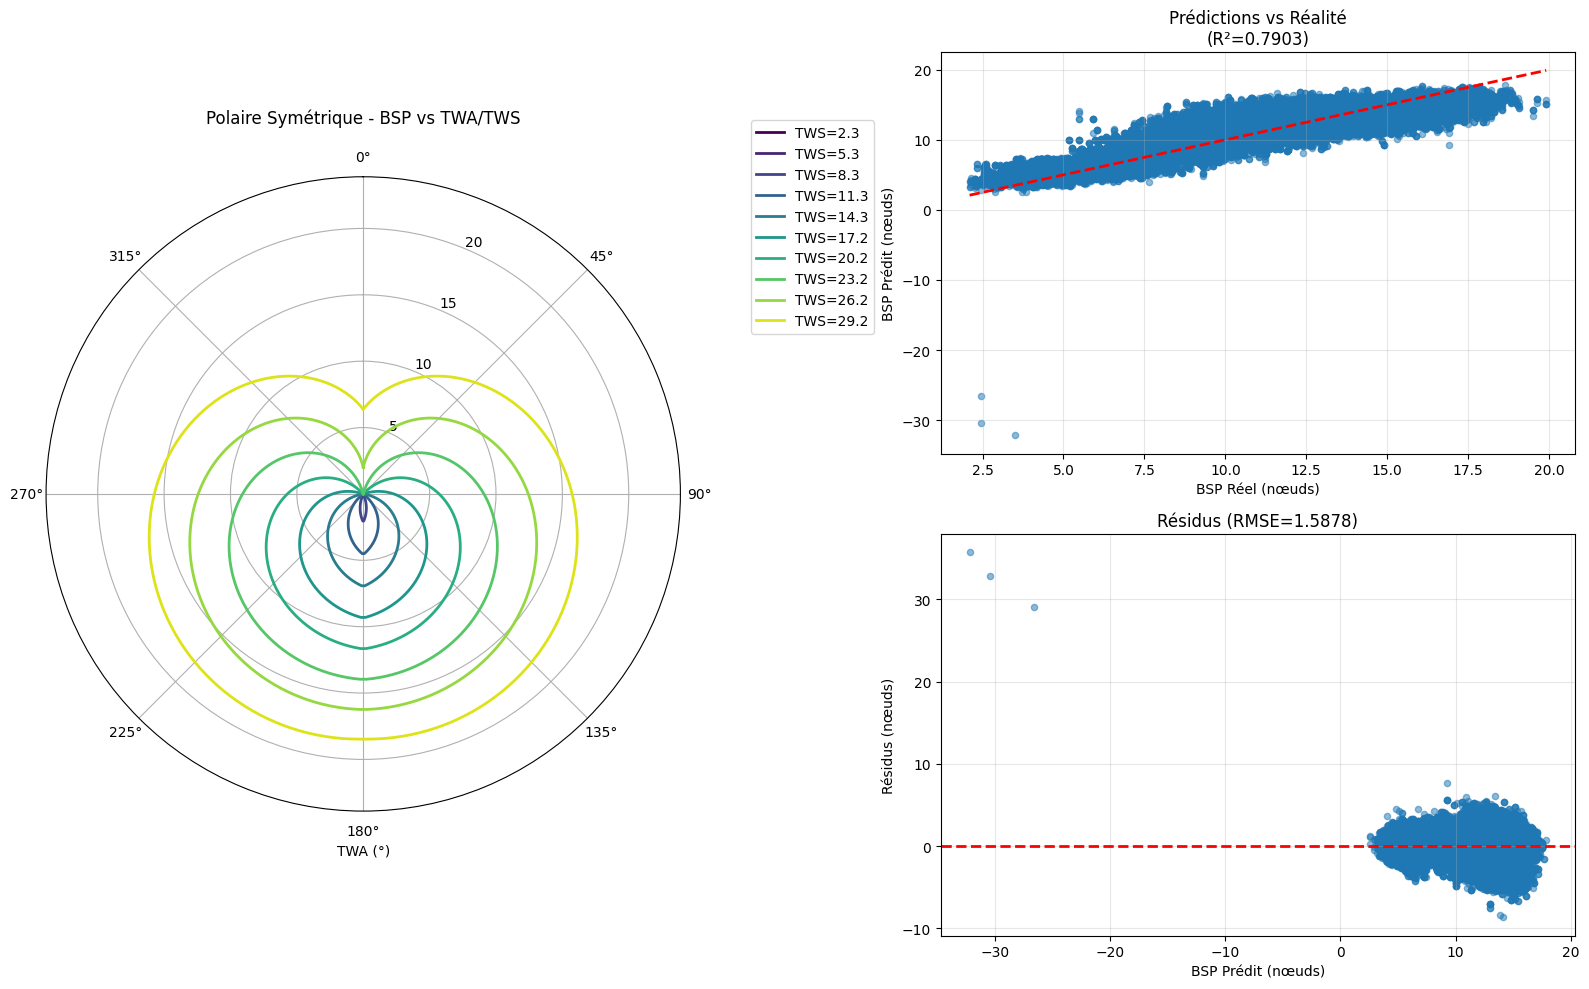

In [3]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt

# 1. Charger et nettoyer les données
df = pd.read_parquet("Cleaned_Data/Cleaned_RDR2018 Sortie Manche.parquet")
df_clean = df[["TWS", "TWA", "BSP"]].dropna()

# 2. Préparer les données
X = df_clean[["TWS", "TWA"]].to_numpy()
y = df_clean["BSP"].to_numpy()

# 3. Régression polynomiale (degré 2)
poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X)

model = LinearRegression()
model.fit(X_poly, y)

# Prédictions sur l'ensemble d'entraînement
y_pred = model.predict(X_poly)

# Métriques de performance
r2 = r2_score(y, y_pred)
mse = mean_squared_error(y, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y, y_pred)

print("="*50)
print("PERFORMANCE DU MODÈLE")
print("="*50)
print(f"R² Score:           {r2:.4f} (0-1, 1 = parfait)")
print(f"Mean Squared Error: {mse:.4f}")
print(f"Root Mean Squared Error: {rmse:.4f} nœuds")
print(f"Mean Absolute Error: {mae:.4f} nœuds")
print(f"Nombre de points:   {len(y)}")
print("="*50)

# 4. Créer la polaire (grille de prédictions)
tws_range = np.linspace(X[:, 0].min(), X[:, 0].max(), 20)
twa_range = np.linspace(0, 180, 20)
tws_grid, twa_grid = np.meshgrid(tws_range, twa_range)

# Prédictions
predictions = []
for tws, twa in zip(tws_grid.flatten(), twa_grid.flatten()):
    sog_pred = model.predict(poly.transform([[tws, twa]]))
    predictions.append(sog_pred[0])

sog_grid = np.array(predictions).reshape(tws_grid.shape)

# 5. Utiliser la polaire
def get_bsp(tws, twa):
    # Appliquer la symétrie
    twa_norm = twa % 360
    if twa_norm > 180:
        twa_norm = 360 - twa_norm
    return model.predict(poly.transform([[tws, twa_norm]]))[0]

print(f"BSP à TWS=12, TWA=90: {get_bsp(12, 90):.2f}")

# 6. Visualiser polaire symétrique + résidus
fig = plt.figure(figsize=(16, 10))

# Subplot 1 : Polaire
ax1 = fig.add_subplot(121, projection='polar')

# Tracer des courbes pour différents TWS
colors = plt.cm.viridis(np.linspace(0, 1, len(tws_range)))
for i, tws_val in enumerate(tws_range[::2]):  # tous les 2 points
    bsp_for_tws = []
    # Tracer de 0° à 360° avec symétrie
    twa_full = np.linspace(0, 360, 180)
    for twa_val in twa_full:
        bsp = get_bsp(tws_val, twa_val)
        bsp_for_tws.append(max(0, bsp))  # éviter valeurs négatives
    
    ax1.plot(np.deg2rad(twa_full), bsp_for_tws, label=f'TWS={tws_val:.1f}', 
            color=colors[i*2], linewidth=2)

# Configuration de l'affichage polaire
ax1.set_theta_offset(np.pi/2)  # 0° en haut
ax1.set_theta_direction(-1)     # sens anti-horaire
ax1.set_ylim(0, y.max() * 1.2)
ax1.set_xlabel('TWA (°)')
ax1.legend(loc='upper left', bbox_to_anchor=(1.1, 1.1))
ax1.set_title('Polaire Symétrique - BSP vs TWA/TWS', pad=20)
ax1.grid(True)

# Subplot 2 : Prédictions vs Réalité
ax2 = fig.add_subplot(222)
ax2.scatter(y, y_pred, alpha=0.5, s=20)
ax2.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
ax2.set_xlabel('BSP Réel (nœuds)')
ax2.set_ylabel('BSP Prédit (nœuds)')
ax2.set_title(f'Prédictions vs Réalité\n(R²={r2:.4f})')
ax2.grid(True, alpha=0.3)

# Subplot 3 : Résidus
ax3 = fig.add_subplot(224)
residus = y - y_pred
ax3.scatter(y_pred, residus, alpha=0.5, s=20)
ax3.axhline(y=0, color='r', linestyle='--', lw=2)
ax3.set_xlabel('BSP Prédit (nœuds)')
ax3.set_ylabel('Résidus (nœuds)')
ax3.set_title(f'Résidus (RMSE={rmse:.4f})')
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
